In [3]:
import pandas as pd

df_exp = pd.read_csv("../data/raw/df_final_experiment_clients.txt")

In [4]:
df_exp 

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control
...,...,...
70604,2443347,NaN
70605,8788427,NaN
70606,266828,NaN
70607,1266421,NaN


In [6]:

# initial structure
print(df_exp.info())
print(df_exp.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  70609 non-null  int64 
 1   Variation  50500 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB
None
   client_id Variation
0    9988021      Test
1    8320017      Test
2    4033851   Control
3    1982004      Test
4    9294070   Control


In [7]:
#  remove rows with missing values
df_exp = df_exp.dropna(subset=["client_id", "Variation"])

In [8]:
#  remove duplicates
df_exp= df_exp.drop_duplicates(subset=["client_id"])


In [10]:
# clean text in Variation column
df_exp["Variation"] = df_exp["Variation"].str.strip().str.lower()

In [12]:
# ensure correct type
df_exp["client_id"] = df_exp["client_id"].astype(int)

In [15]:
# check missing values
print(df_exp.isna().sum())

# check duplicates
print(df_exp.duplicated().sum())

# check unique values
print(df_exp["Variation"].unique())

client_id    0
Variation    0
dtype: int64
0
['test' 'control']


In [14]:
# check unique values
print(df_exp["Variation"].value_counts())


Variation
test       26968
control    23532
Name: count, dtype: int64


In [18]:
# save cleaned dataset
df_exp.to_csv("df_final_experiment_clients_clean.csv", index=False)

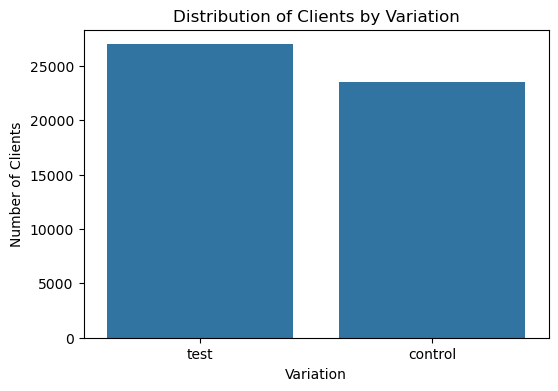

In [20]:

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("df_final_experiment_clients_clean.csv")

plt.figure(figsize=(6,4))
sns.countplot(x="Variation", data=df)

plt.title("Distribution of Clients by Variation")
plt.xlabel("Variation")
plt.ylabel("Number of Clients")

plt.show()

In [21]:
variation_percent = df["Variation"].value_counts(normalize=True) * 100

print(variation_percent)

Variation
test       53.40198
control    46.59802
Name: proportion, dtype: float64
